In [1]:
import os
from os.path import expanduser
home = expanduser("~/")

import sys
# sys.path.insert(0, '/global/u2/x/xshuang/gigalens-xh-dev/src')

# import sys
conda_env = sys.path[1]
del sys.path[1]

import os
# sys.path.append(f'{os.environ['HOME']}/gigalens_personal/gigalens/src')
sys.path.append(home+'/gigalens'+'/src')
sys.path.append(conda_env)
sys.path.append(home+'/GIGALens-Code/')
print(sys.path)



srcdir = os.path.join(home, "gigalens/src/")


['', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '/usr/local/lib/python3.12/dist-packages', '__editable__.flax-0.10.6.finder.__path_hook__', '__editable__.jax_cuda12_pjrt-0.6.2.dev20250607.finder.__path_hook__', '__editable__.jax_cuda12_plugin-0.6.2.dev20250607.finder.__path_hook__', '__editable__.nsys_jax-0.1.dev1163+g4a8f06a.finder.__path_hook__', '/opt/pip/src', '/usr/lib/python3/dist-packages', '/global/homes/l/linusu//gigalens/src', '/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages', '/global/homes/l/linusu//GIGALens-Code/']


In [2]:
import tensorflow_probability.substrates.jax as tfp

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear

import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
import corner
import yaml
import pickle
from helpers import *
import blackjax
import importlib
from helpers import *
from mclmc_alt import MCLMC
import pandas as pd
tfd = tfp.distributions

2026-02-14 09:38:27.308350: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771090707.464377 2219310 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771090707.501787 2219310 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771090707.798387 2219310 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771090707.798406 2219310 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771090707.798408 2219310 computation_placer.cc:177] computation placer alr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
kernel = np.load(os.path.join(srcdir, 'gigalens/assets/psf.npy')).astype(np.float32)
prior = make_default_prior()

phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False)])
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=80, supersample=2, kernel=kernel) 
lens_sim = LensSimulator(phys_model, sim_config, bs=1)

systems_dir = os.path.join(home, "GIGALens-Code/SystemSaves")

f = np.load(os.path.join(systems_dir, "100SystemsStandard80px.npz"))
keys = f.files
observed_imgs = jnp.array([f[key] for key in keys])

In [4]:
from tensorflow_probability.substrates.jax import (
    distributions as tfd,
    bijectors as tfb,
    experimental as tfe,
)
from jax import pmap, jit
def HMC_multi(
            self,
            q_z,
            init_eps=0.3,
            init_l=3,
            n_hmc=50,
            num_burnin_steps=250,
            num_results=750,
            max_leapfrog_steps=30,
            seed=0,
    ):
        dev_cnt = len(jax.devices())
        local_dev_cnt = len(jax.local_devices())
        # seeds are per process (node)
        seeds = jax.random.split(jax.random.fold_in(jax.random.PRNGKey(seed), jax.process_index()), local_dev_cnt)
        n_hmc = (n_hmc // dev_cnt) * dev_cnt
        lens_sim = LensSimulator(
            self.phys_model,
            self.sim_config,
            bs=n_hmc // dev_cnt,
        )
        momentum_distribution = tfd.MultivariateNormalFullCovariance(
            loc=jnp.zeros_like(q_z.mean()),
            covariance_matrix=jnp.linalg.inv(q_z.covariance()),
        )

        @jit
        def log_prob(z):
            return self.prob_model.log_prob(lens_sim, z)[0]

        @pmap
        def run_chain(seed):
            start = q_z.sample(n_hmc // dev_cnt, seed=seed)
            num_adaptation_steps = int(num_burnin_steps * 0.8)
            mc_kernel = tfe.mcmc.PreconditionedHamiltonianMonteCarlo(
                target_log_prob_fn=log_prob,
                momentum_distribution=momentum_distribution,
                step_size=init_eps,
                num_leapfrog_steps=init_l,
                store_parameters_in_results=True,
            )

            mc_kernel = tfe.mcmc.GradientBasedTrajectoryLengthAdaptation(
                mc_kernel,
                num_adaptation_steps=num_adaptation_steps,
                max_leapfrog_steps=max_leapfrog_steps,
            )
            mc_kernel = tfp.mcmc.DualAveragingStepSizeAdaptation(
                inner_kernel=mc_kernel, num_adaptation_steps=num_adaptation_steps
            )

            def trace_L(states, previous_kernel_results):
                # return mc_kernel.inner_kernel.num_leapfrog_steps_getter_fn(previous_kernel_results)# previous_kernel_results.num_leapfrog_steps
                return previous_kernel_results.inner_results.inner_results.proposed_results.num_leapfrog_steps

            return tfp.mcmc.sample_chain(
                num_results=num_results,
                num_burnin_steps=num_burnin_steps,
                current_state=start,
                trace_fn=trace_L,#lambda _, pkr: None,
                seed=seed,
                kernel=mc_kernel,
                # return_final_kernel_results=True,
            )

        start = time.time()
        samples = run_chain(seeds)
        end = time.time()
        # aggregate over all devices

        # print(f"LEAPFROG STEPS: {samples.num_leapfrog_steps_getter_fn(samples)}")

        # process_mesh = jax.make_mesh((local_dev_cnt,), ('local_device',))
        # sharding = jax.sharding.NamedSharding(process_mesh, P('local_device', None, None, None)) 
        # print(f'{samples.all_states.shape=}')
        # process_samples = jax.make_array_from_process_local_data(sharding, samples.all_states)
        # print(f'{process_samples.shape=}')
        # all_samples is (num_processes, num_devices_per_process, num_steps, n_hmc_per_device, 22)
        all_samples = jax.experimental.multihost_utils.process_allgather(samples.all_states)
        total_leapfrog_steps = jax.experimental.multihost_utils.process_allgather(samples.trace)
        # print(all_samples.reshape(all_samples.shape[0] * all_samples.shape[1], *all_samples.shape[2:]).shape)
        # reshape to (num_devices, num_steps, n_hmc_per_device, , 22), then swap num_steps, n_hmc_per_device
        device_partitioned_samples = jnp.swapaxes(all_samples.reshape(all_samples.shape[0] * all_samples.shape[1], *all_samples.shape[2:]), 1, 2)
        # chain_partitioned_samples is (num_chains, num_steps, 22)
        # chain_partitioned_samples = device_partitioned_samples.reshape(device_partitioned_samples.shape[0] * device_partitioned_samples.shape[1], *device_partitioned_samples.shape[2:])
        return device_partitioned_samples, total_leapfrog_steps

In [5]:
normal_results_loc = os.path.join(home, f"GIGALens-Code/pipeline_results/100standard80px")
save_loc = os.path.join(home, f"GIGALens-Code/pipeline_results/100standard80px_mclmc_no_svi")
# save_loc_refined = os.path.join(home, f"GIGALens-Code/pipeline_results/100standard80px_mclmc_refined")
hmc_save_loc = os.path.join(home, f"GIGALens-Code/pipeline_results/100standard80px_count_leapfrog")

In [34]:
background_rms=0.2
exp_time=100
n_hmc = 16
idxes = list(range(100)) #[28, 45, 60, 79, 82]#

In [33]:
import mclmc_alt
importlib.reload(mclmc_alt)
from mclmc_alt import MCLMC
for i in idxes:
    
    observed_img = observed_imgs[i]
    prob_model = ForwardProbModel(prior, observed_img, background_rms=background_rms, exp_time=exp_time)
    model_seq = ModellingSequence(phys_model, prob_model, sim_config)

    results_dir = os.path.join(home, normal_results_loc, f"{i}")

    results = {}
    results["MAP"] = MAPResults.load(results_dir, model_seq)
    results["SVI"] = SVIResults.load(results_dir, model_seq)
    # results["HMC"] = HMCResults.load(results_dir, model_seq)


    # HMC_smp, num_leapfrog = HMC_multi(model_seq, results["SVI"].qz, n_hmc=n_hmc, num_burnin_steps=500, num_results=1500)

    # hmc_results = HMCResults(HMC_smp, -1, model_seq)
    
    # total_leapfrog_steps = jnp.mean(jnp.sum(jnp.squeeze(num_leapfrog), axis=1)) * n_hmc
    # print(i, ": Total Leapfrog Steps Per Chain:", total_leapfrog_steps/n_hmc)

    # save_dir = os.path.join(home, hmc_save_loc, f"{i}")
    # if not os.path.exists(save_dir):
    #     os.makedirs(save_dir)
        
    # hmc_results.save(save_dir)

    # # Log the number of leapfrog steps HMC takes
    # csv_path = os.path.join(hmc_save_loc, "leapfrog_steps.csv")
    # if os.path.exists(csv_path):
    #     df = pd.read_csv(csv_path)
    # else:
    #     df = pd.DataFrame({'system':[], 'n_leapfrog':[]})

    # df = pd.concat([
    #     df, 
    #     pd.DataFrame({'system':[i], 'n_leapfrog':[total_leapfrog_steps]})]
    # ).reset_index(drop=True)
    # df = df.to_csv(csv_path, index=False)

    def log_prob(z):
        return prob_model.log_prob(lens_sim, z)[0]
    
    default_start = jnp.diag(jnp.ones((22,))) * 1e-3
    no_SVI_qz = tfd.MultivariateNormalTriL(loc=jnp.squeeze(results['MAP'].best_z), scale_tril=default_start)
    

    mclmc_samples = MCLMC(
        model_seq,
        no_SVI_qz, #results["SVI"].qz
        n_hmc=n_hmc,
        num_burnin_steps=10000,
        num_results=10000,
    )

    mclmc_rhat = np.max(blackjax.diagnostics.potential_scale_reduction(mclmc_samples, chain_axis=0, sample_axis=1))
    # hmc_rhat = np.max(results["HMC"].HMC_rhat)
    print(f"System {i}: MCLMC Rhat {mclmc_rhat}")#, HMC Rhat {hmc_rhat}")

    mclmc_results = HMCResults(mclmc_samples[jnp.newaxis, ...], -1, model_seq)

    

    save_dir = os.path.join(home, save_loc, f"{i}")
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        
    mclmc_results.save(save_dir)

Min ESS: 4.781242370605469 < 10, L adapt may be iffy
Burnin Time: 152.19481234508567
Sampling took 106.49045236501843 s
System 60: MCLMC Rhat 1.0064237117767334
Burnin Time: 149.31872633297462
Sampling took 106.23575740598608 s
System 79: MCLMC Rhat 1.0036665201187134


In [9]:
samples = mclmc_samples.reshape(-1, 22) #samples_mclmc 
MCMC_x = prob_model.bij.forward(list(samples.T))
plot_params = cornerplot_labels(MCMC_x)
fig = cornerplot_posterior(MCMC_x, color='red',plot_params=plot_params)
plt.show()

NameError: name 'mclmc_samples' is not defined

In [13]:
jnp.diag(results["SVI"].qz.scale_tril)

Array([0.02656728, 0.01574657, 0.02841325, 0.03676566, 0.07651892,
       0.01669485, 0.01431121, 0.01024949, 0.01149139, 0.00159058,
       0.00066476, 0.00082975, 0.1410743 , 0.02216172, 0.00300464,
       0.13725954, 0.01794981, 0.00236129, 0.00247942, 0.1063476 ,
       0.11321894, 0.04579748], dtype=float32)

In [7]:

def rhat_plot(ax, chain_samples, grad_evals_per_result, color='black', num_plot_points=30, label=None):
    sample_length = np.linspace(20, chain_samples.shape[1], num_plot_points).astype(int)#list(range(20, chain_samples.shape[1]+1, step)) + [chain_samples.shape[1]]
    rhats = -np.ones((len(sample_length), chain_samples.shape[-1]))
    for i, l in enumerate(sample_length):
        rhats[i] = blackjax.diagnostics.potential_scale_reduction(chain_samples[:, :l, :], chain_axis=0, sample_axis=1)
    
    n_grads = np.array(sample_length)*grad_evals_per_result
    ax.plot(n_grads, jnp.max(rhats-1, axis=1), linestyle='-', color=color, label=label)
    # ax.plot(n_grads, jnp.min(rhats-1, axis=1), linestyle='--', color=color)
    # ax.plot(n_grads, jnp.mean(rhats-1, axis=1), linestyle='-', color=color)

def ess_plot(ax, chain_samples, grad_evals_per_result, color='black', num_plot_points=10, label=None):
    sample_length = np.linspace(20, chain_samples.shape[1], num_plot_points).astype(int)#list(range(20, chain_samples.shape[1]+1, 400)) + [chain_samples.shape[1]]
    ess = -np.ones((len(sample_length), chain_samples.shape[-1]))
    for i, l in enumerate(sample_length):
        ess[i] = blackjax.diagnostics.effective_sample_size(chain_samples[:, :l, :], chain_axis=0, sample_axis=1)
    
    n_grads = np.array(sample_length)*grad_evals_per_result
    ax.plot(n_grads, jnp.min(ess, axis=1), linestyle='-', color=color, label=label)

    

In [8]:
#* Load data for how many leapfrog steps (and thus gradient evals) HMC takes
csv_path = os.path.join(hmc_save_loc, "leapfrog_steps.csv")
leapfrog_df = pd.read_csv(csv_path).astype({'system': int}).set_index('system')

#* How many gradient evals does MCLMC take?
from mclmc_alt import mclachlan_coefficients
n_grad_per_integration_step_mclachlan = len(mclachlan_coefficients)//2 #* Happens on every odd step of the integrator

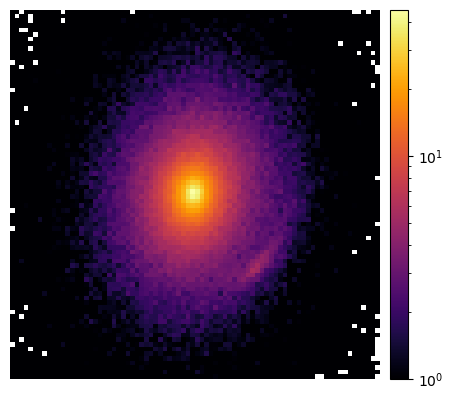

In [11]:
plot_image(plt.gcf(), plt.gca(), observed_imgs[81])
plt.show()

In [26]:
a = prob_model.bij.forward(list(np.moveaxis(mclmc_samples, -1, 0)))

In [33]:
jax.tree.map(lambda x: jnp.mean(x), a)

[[{'center_x': Array(-0.01714211, dtype=float32),
   'center_y': Array(0.02628073, dtype=float32),
   'e1': Array(0.16216694, dtype=float32),
   'e2': Array(-0.02219681, dtype=float32),
   'gamma': Array(1.9850475, dtype=float32),
   'theta_E': Array(0.91212475, dtype=float32)},
  {'gamma1': Array(-0.03644456, dtype=float32),
   'gamma2': Array(0.07114703, dtype=float32)}],
 [{'Ie': Array(345.78403, dtype=float32),
   'R_sersic': Array(1.6651398, dtype=float32),
   'center_x': Array(-0.01420752, dtype=float32),
   'center_y': Array(0.00878678, dtype=float32),
   'e1': Array(-0.13918646, dtype=float32),
   'e2': Array(0.0503573, dtype=float32),
   'n_sersic': Array(2.512739, dtype=float32)}],
 [{'Ie': Array(90.292984, dtype=float32),
   'R_sersic': Array(0.24020493, dtype=float32),
   'center_x': Array(0.461457, dtype=float32),
   'center_y': Array(-0.28732598, dtype=float32),
   'e1': Array(-0.04127383, dtype=float32),
   'e2': Array(0.16423617, dtype=float32),
   'n_sersic': Array(2.2

In [32]:
a[0][0].keys()#['center_y'].shape

dict_keys(['theta_E', 'gamma', 'e2', 'e1', 'center_y', 'center_x'])

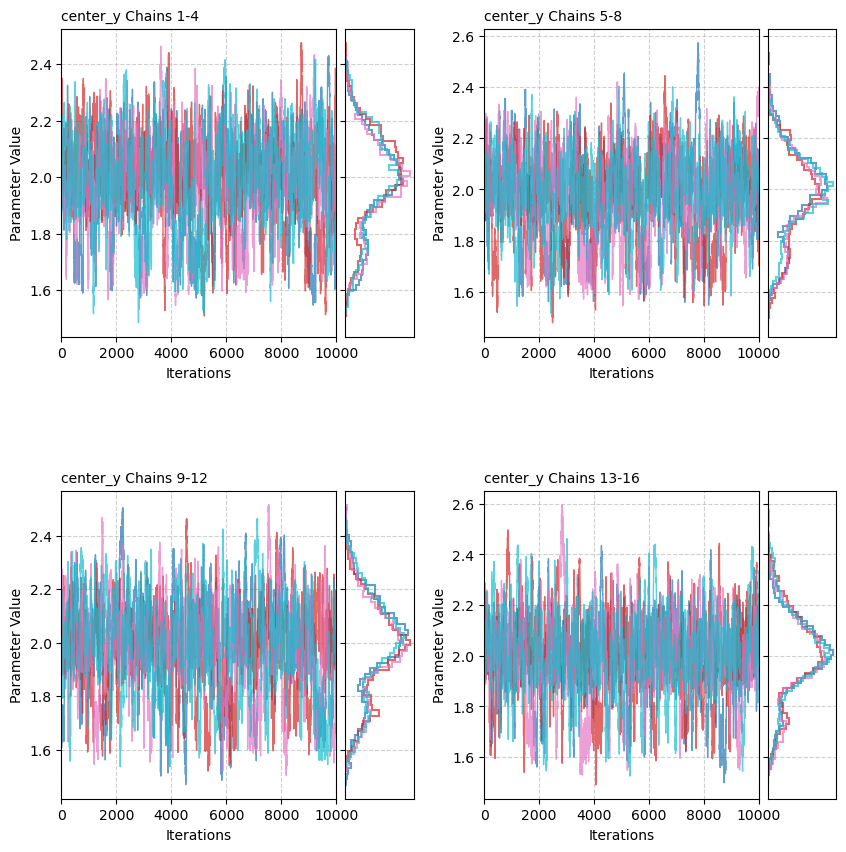

In [34]:
import matplotlib.gridspec as gridspec

def plot_trace_and_hist(fig, spec, all_data, title=""):
    
    nested_gs = spec.subgridspec(1, 2, width_ratios=[4, 1], wspace=0.05)
    ax_trace = fig.add_subplot(nested_gs[0, 0])
    ax_hist = fig.add_subplot(nested_gs[0, 1], sharey=ax_trace)
    
    num_chains, num_samples = all_data.shape
    
    colors = plt.get_cmap('tab10', num_chains)
    
    for i in range(num_chains):
        chain_data = all_data[i]
        color = colors(i)

        ax_trace.plot(chain_data, color=color, alpha=0.7, linewidth=1)
        ax_hist.hist(chain_data, 
                     bins=50, 
                     orientation='horizontal', 
                     density=True, 
                     color=color, 
                     alpha=0.7, 
                     histtype='step', 
                     linewidth=1.5)
                     
    
    # Style trace plot
    ax_trace.set_title(title, loc='left', fontsize='medium')
    ax_trace.set_xlabel("Iterations")
    ax_trace.set_ylabel("Parameter Value")
    ax_trace.grid(True, linestyle='--', alpha=0.6)
    ax_trace.set_xlim(0, num_samples) # Ensure x-axis starts at 0
    
    # Style histogram plot
    ax_hist.set_xticks([]) # Remove x-axis ticks (density values)
    plt.setp(ax_hist.get_yticklabels(), visible=False) # Hide y-axis labels
    ax_hist.grid(True, linestyle='--', alpha=0.6)
    
    return ax_trace, ax_hist

fig = plt.figure(figsize=(10, 10))
main_gs = fig.add_gridspec(2, 2, hspace=0.5) # Add vertical space

# --- 2. Loop and create each plot ---
for i in range(2):
    for j in range(2):

        k = 2*i + j
        step = 16//4
        
        # Generate some fake data for this plot
        # Each plot will have a different mean and scale
        data = jnp.squeeze(a[0][0]['gamma'])[step*k:step*(k+1)]
        
        # Call our function to create the plot in the correct grid location
        plot_trace_and_hist(fig, 
                            main_gs[i, j], 
                            data, 
                            title=f"center_y Chains {step*k+1}-{step*(k+1)}")
                        
# --- 3. Show the final figure ---
# fig.suptitle("Tiled Trace & Histogram Plots", fontsize=16, y=0.99)
# plt.tight_layout(rect=[0, 0, 1, 1]) # Adjust for suptitle

# Save or show the plot
# plt.savefig("tiled_plots.png", dpi=150)
plt.show()

In [9]:
i = 60

observed_img = observed_imgs[i]
prob_model = ForwardProbModel(prior, observed_img, background_rms=background_rms, exp_time=exp_time)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

results_dir = os.path.join(home, hmc_save_loc, f"{i}")
hmc_smp = HMCResults.load(results_dir, model_seq).HMC_samples_z

HMC_grad_evals = leapfrog_df['n_leapfrog'][i]
HMC_grad_evals_per_result = HMC_grad_evals/(hmc_smp.shape[-2])

save_dir_refined = os.path.join(home, save_loc_refined, f"{i}")
if os.path.exists(save_dir_refined):
    print("Using refined (longer) samples")
    save_dir = save_dir_refined
else:
    save_dir = os.path.join(home, save_loc, f"{i}")

mclmc_smp = HMCResults.load(save_dir, model_seq).HMC_samples_z
mclmc_grad_evals_per_result = n_grad_per_integration_step_mclachlan * n_hmc

fig, (ax1, ax2) = plt.subplots(1,2)
fig.set_size_inches(13, 5)

rhat_plot(ax1, hmc_smp.reshape(16, 1500, 22), HMC_grad_evals_per_result, color='black', label='HMC')
rhat_plot(ax1, mclmc_smp.reshape(16, mclmc_smp.shape[-2], 22), mclmc_grad_evals_per_result, color='red', label='MCLMC')
ax1.axhline(1e-2, linestyle='--', label=r'$\hat{R} < 1.01$ Convergence')
ax1.set_yscale('log')
ax1.set_ylabel(r"$\hat{R}-1$")
ax1.set_xlabel("Gradient Evaluations")
ax1.legend()

ess_plot(ax2, hmc_smp.reshape(16, 1500, 22), HMC_grad_evals_per_result, color='black', label='HMC')
ess_plot(ax2, mclmc_smp.reshape(16, mclmc_smp.shape[-2], 22), mclmc_grad_evals_per_result, color='red', label='MCLMC')
# ax1.axhline(1e-2, linestyle='--', label=r'$\hat{R} < 1.01$ Convergence')
# ax1.set_yscale('log')
ax2.set_ylabel(r"ESS")
ax2.set_xlabel("Gradient Evaluations")
ax2.legend()
fig.suptitle(f"System {i}")

plt.show()

NameError: name 'save_loc_refined' is not defined

In [35]:
hmc_max_rhat = []
mclmc_max_rhat = []

hmc_min_ess = []
mclmc_min_ess = []

median_diffs = []
lower_errs = []
upper_errs = []

for i in idxes:
    observed_img = observed_imgs[i]
    prob_model = ForwardProbModel(prior, observed_img, background_rms=0.2, exp_time=100)
    model_seq = ModellingSequence(phys_model, prob_model, sim_config)

    
    hmc_dir = os.path.join(hmc_save_loc, f"{i}")
    hmc_results = HMCResults.load(hmc_dir, model_seq)
    smp = hmc_results.HMC_samples_z
    
    HMC_by_chain = hmc_results.HMC_samples_z.reshape((smp.shape[0]*smp.shape[1], smp.shape[2], smp.shape[3]))
    hmc_rhat = np.max(blackjax.diagnostics.potential_scale_reduction(HMC_by_chain, chain_axis=0, sample_axis=1))
    hmc_ess = blackjax.diagnostics.effective_sample_size(HMC_by_chain, chain_axis=0, sample_axis=1)

    hmc_grad_evals = leapfrog_df['n_leapfrog'][i]
    hmc_ess_per_grad = np.min(hmc_ess)/hmc_grad_evals
    
    hmc_max_rhat.append(hmc_rhat)
    hmc_min_ess.append(hmc_ess_per_grad)
    

    # save_dir_refined = os.path.join(home, save_loc_refined, f"{i}")
    # if os.path.exists(save_dir_refined):
    #     print("Using refined (longer) samples")
    #     save_dir = save_dir_refined
    # else:
    save_dir = os.path.join(home, save_loc, f"{i}")
    
    mclmc_results = HMCResults.load(save_dir, model_seq)
    mclmc_smp = jnp.squeeze(mclmc_results.HMC_samples_z)

    mclmc_rhat = jnp.max(blackjax.diagnostics.potential_scale_reduction(mclmc_smp, chain_axis=0, sample_axis=1))
    mclmc_ess = blackjax.diagnostics.effective_sample_size(mclmc_smp, chain_axis=0, sample_axis=1)

    mclmc_grad_evals = n_grad_per_integration_step_mclachlan * mclmc_smp.shape[0] * mclmc_smp.shape[1]
    mclmc_ess_per_grad = np.min(mclmc_ess)/mclmc_grad_evals

    mclmc_max_rhat.append(mclmc_rhat)
    mclmc_min_ess.append(mclmc_ess_per_grad)
    print(f"System {i}: HMC Max Rhat {hmc_rhat:.4f}, MCLMC Max Rhat {mclmc_rhat:.4f}, HMC ESS/grad: {hmc_ess_per_grad}, MCLMC ESS/grad: {mclmc_ess_per_grad}")


    # diff, low, high = get_errors_diff(mclmc_results.HMC_samples, hmc_results.HMC_median)

    # median_diffs.append(diff)
    # lower_errs.append(low)
    # upper_errs.append(high)
    # print(i)


# median_diffs = flatten_params_to_labeled_dict(list_to_tree(median_diffs))
# upper_errs = flatten_params_to_labeled_dict(list_to_tree(upper_errs))
# lower_errs = flatten_params_to_labeled_dict(list_to_tree(lower_errs))

hmc_max_rhat = jnp.array(hmc_max_rhat)
mclmc_max_rhat = jnp.array(mclmc_max_rhat)
hmc_min_ess = jnp.array(hmc_min_ess)
mclmc_min_ess = jnp.array(mclmc_min_ess)

System 0: HMC Max Rhat 1.0268, MCLMC Max Rhat 1.0029, HMC ESS/grad: 0.002772824838757515, MCLMC ESS/grad: 0.025366831570863724
System 1: HMC Max Rhat 1.0015, MCLMC Max Rhat 1.0005, HMC ESS/grad: 0.04759029671549797, MCLMC ESS/grad: 0.04404475912451744
System 2: HMC Max Rhat 1.0008, MCLMC Max Rhat 1.0007, HMC ESS/grad: 0.06375531852245331, MCLMC ESS/grad: 0.11346800625324249
System 3: HMC Max Rhat 1.0048, MCLMC Max Rhat 1.0033, HMC ESS/grad: 0.016368797048926353, MCLMC ESS/grad: 0.04279430955648422
System 4: HMC Max Rhat 1.0131, MCLMC Max Rhat 1.0026, HMC ESS/grad: 0.007061077747493982, MCLMC ESS/grad: 0.03550777584314346
System 5: HMC Max Rhat 1.1689, MCLMC Max Rhat 1.0063, HMC ESS/grad: 0.00022527606051880866, MCLMC ESS/grad: 0.020247356966137886
System 6: HMC Max Rhat 1.0010, MCLMC Max Rhat 1.0013, HMC ESS/grad: 0.06410859525203705, MCLMC ESS/grad: 0.10634841024875641
System 7: HMC Max Rhat 1.0113, MCLMC Max Rhat 1.0037, HMC ESS/grad: 0.0038325097411870956, MCLMC ESS/grad: 0.01631110

In [39]:
np.where(mclmc_max_rhat>1.01)

(array([], dtype=int64),)

In [20]:
def list_to_tree(list_of_trees):
    return jax.tree.map(lambda *xs: jnp.array(xs), *list_of_trees)


# n_params=22
# fig, axs = plt.subplots(n_params//3 + 1, 3)
# fig.set_size_inches(20,25)
# axs = axs.flatten()

out = []
for i, label in enumerate(median_diffs.keys()):
    z_scores, chisq = normalize_residuals(median_diffs[label], upper_errs[label], lower_errs[label])
    outliers = jnp.where(jnp.abs(z_scores) > 0.2)[0]
    if len(outliers) > 0:
        print(f"{label} has outliers at indices: {outliers}")
    # histogram_residuals(fig, axs[i], z_scores, f'{label}, chisq: {chisq:.3f}', bins=10)

# plt.show()

mass_0center_y has outliers at indices: [60]
mass_0e2 has outliers at indices: [60]
mass_0gamma has outliers at indices: [28 60]
mass_0theta_E has outliers at indices: [60]
mass_1gamma1 has outliers at indices: [60]
mass_1gamma2 has outliers at indices: [60]
src_0Ie has outliers at indices: [60]
src_0R_sersic has outliers at indices: [60]
src_0center_x has outliers at indices: [28 60]
src_0center_y has outliers at indices: [60]
src_0e1 has outliers at indices: [60]
src_0e2 has outliers at indices: [60]
src_0n_sersic has outliers at indices: [60]


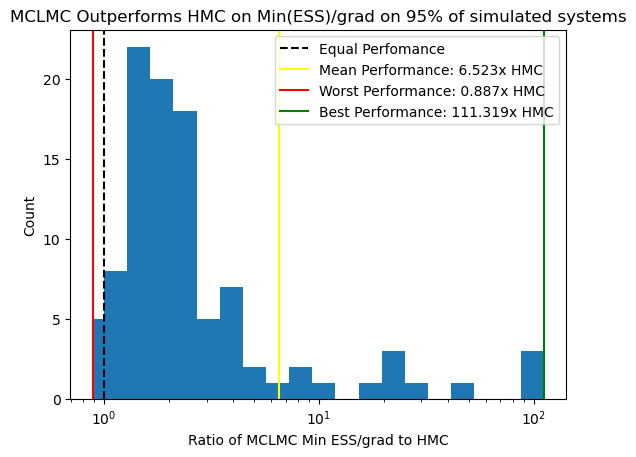

In [36]:
ratio = mclmc_min_ess/hmc_min_ess
failed_mask = np.ones_like(ratio, dtype=bool)
ratio_plot = ratio[failed_mask]


#* Annoying binning to make sure bins split at 1
bins=22
frac_over = np.mean(ratio_plot>1)
bins_under = int(np.ceil((1-frac_over)*bins))
bins_over = int(np.floor(frac_over*bins))
bins = np.concat([np.logspace(np.log10(np.min(ratio_plot)), 0, bins_under), np.logspace(0, np.log10(np.max(ratio_plot)+0.1), bins_over)])
#* End of annoying binning code

plt.xscale('log')
hist = plt.hist(ratio_plot,bins=bins) 
plt.axvline(1, label="Equal Perfomance", color='black', linestyle="--")
plt.axvline(np.mean(ratio_plot), label=f"Mean Performance: {np.mean(ratio_plot):.3f}x HMC", color='yellow')
plt.axvline(np.min(ratio_plot), label=f"Worst Performance: {np.min(ratio_plot):.3f}x HMC", color='red')
plt.axvline(np.max(ratio_plot), label=f"Best Performance: {np.max(ratio_plot):.3f}x HMC", color='green')
plt.legend()
plt.xlabel("Ratio of MCLMC Min ESS/grad to HMC")
plt.ylabel("Count")
plt.title(f"MCLMC Outperforms HMC on Min(ESS)/grad on {frac_over*100:.0f}% of simulated systems")
plt.show()

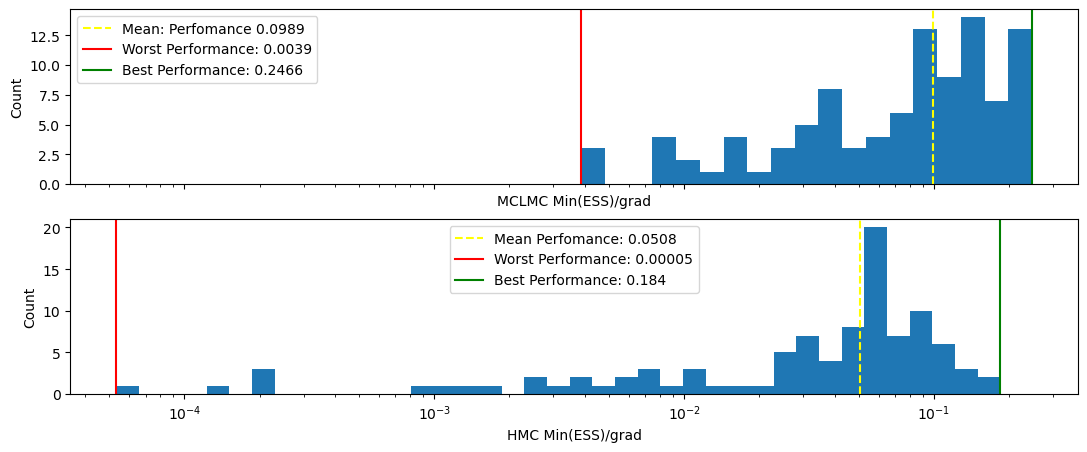

In [37]:
ess = mclmc_min_ess
failed_mask = np.ones_like(ess, dtype=bool)
ess_plot = ess[failed_mask]

fig, (ax1, ax2) = plt.subplots(2,1, sharex=True)
fig.set_size_inches(13, 5)


bins = np.logspace(np.log10(np.min(ess_plot))-0.001, np.log10(np.max(ess_plot)), 20)

ax1.set_xscale('log')
hist = ax1.hist(ess_plot,bins=bins) 
ax1.axvline(np.mean(ess_plot), label=f"Mean: Perfomance {np.mean(ess_plot):.4f}", color='yellow', linestyle="--")
ax1.axvline(np.min(ess_plot), label=f"Worst Performance: {np.min(ess_plot):.4f}", color='red')
ax1.axvline(np.max(ess_plot), label=f"Best Performance: {np.max(ess_plot):.4f}", color='green')
ax1.legend()
ax1.set_xlabel("MCLMC Min(ESS)/grad")
ax1.set_ylabel("Count")

ess = hmc_min_ess
failed_mask = np.ones_like(ess, dtype=bool)
failed_mask[13] = 0
ess_plot = ess[failed_mask]

bins = np.logspace(np.log10(np.min(ess_plot))-0.001, np.log10(np.max(ess_plot)), 40)

ax2.set_xscale('log')
hist = ax2.hist(ess_plot,bins=bins) 
ax2.axvline(np.mean(ess_plot), label=f"Mean Perfomance: {np.mean(ess_plot):.4f}", color='yellow', linestyle="--")
ax2.axvline(np.min(ess_plot), label=f"Worst Performance: {np.min(ess_plot):.5f}", color='red')
ax2.axvline(np.max(ess_plot), label=f"Best Performance: {np.max(ess_plot):.3f}", color='green')
ax2.legend()
ax2.set_xlabel("HMC Min(ESS)/grad")
ax2.set_ylabel("Count")
plt.show()

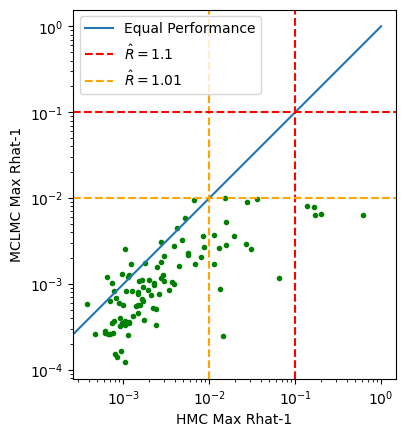

In [38]:
# plt.plot(np.array(hmc_max_rhat)-1, 'r.')
# plt.plot(np.array(mclmc_max_rhat)-1, 'b^')
plt.plot(hmc_max_rhat[failed_mask]-1, mclmc_max_rhat[failed_mask]-1, 'g.')
plt.plot(np.linspace(0, 1.0, 10), np.linspace(0, 1.0, 10), label='Equal Performance')
plt.xlabel('HMC Max Rhat-1')
plt.ylabel('MCLMC Max Rhat-1')
plt.yscale('log')
plt.xscale('log')
plt.axvline(0.1, color='orange', linestyle='--', label=r"$\hat{R}=1.1$", )
plt.axvline(0.01, color='red', linestyle='--', label=r"$\hat{R}=1.01$")
plt.axhline(0.1, color='orange', linestyle='--')
plt.axhline(0.01, color='red', linestyle='--')
plt.legend()
plt.gca().set_aspect('equal')
plt.show()

In [32]:
# n_grad_evals_mclmc = num_steps
n_grad_evals_mclmc = multi_chain_samples.shape[0]*multi_chain_samples.shape[1]
# ESS_mclmc = blackjax.diagnostics.effective_sample_size(samples_mclmc[np.newaxis, :,:], chain_axis=0, sample_axis=1)
ESS_mclmc = blackjax.diagnostics.effective_sample_size(multi_chain_samples, chain_axis=0, sample_axis=1)

print(ESS_mclmc)
print(np.mean(ESS_mclmc)/n_grad_evals_mclmc, " | ", jnp.min(ESS_mclmc)/n_grad_evals_mclmc)

[5908.65   6053.0024 3359.7722 3778.472  2240.9536 6034.2656 2947.7896
 4956.653  6160.2744 6047.194  6356.1494 6376.4375 6394.3325 3219.6565
 6243.636  4781.986  5485.0034 6188.248  2406.9727 6402.1553 6383.4414
 4883.0347]
0.10663642  |  0.046686534


In [33]:
rhat = blackjax.diagnostics.potential_scale_reduction(multi_chain_samples, chain_axis=0, sample_axis=1)
print(rhat)
print(jnp.max(rhat))

[1.0005153 1.001177  1.0023904 1.0014701 1.0024804 1.0005126 1.0016395
 1.0015275 1.00095   1.0009768 1.0005072 1.0003084 1.0009599 1.0022622
 1.0008458 1.001441  1.0009844 1.0002912 1.0023963 1.0007858 1.0012782
 1.0014398]
1.0024804


In [55]:
chain_len = results['HMC'].HMC_samples_z[0, 1].shape[0]
hmc_1chain_ESS = blackjax.diagnostics.effective_sample_size(results['HMC'].HMC_samples_z[0, 4][np.newaxis, :,:], chain_axis=0, sample_axis=1)
print(np.mean(hmc_1chain_ESS)/(chain_len*10), " | ", jnp.min(hmc_1chain_ESS)/(chain_len*10)) # 10 is guess at leapfrog steps per sample taken

3.1863703e-05  |  2.282083e-06
